# **Fine-Tuning BERT on a IMDB Dataset**

In [ ]:
!pip install transformers torch scikit-learn pandas tqdm

In [ ]:
import pandas as pd
import re
import torch
import transformers
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Load Dataset

In [ ]:
df = pd.read_csv('IMDB Dataset.csv')
df.head()

In [ ]:
df.info()

In [ ]:
df = df.dropna()
df = df.reset_index(drop=True)

In [ ]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)          # Remove HTML
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # Remove special chars
    text = text.lower()                        # Lowercase
    return text

df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
df['label'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

# Split train dataset into train, validation and test sets

In [ ]:
X = df['clean_review']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Import BERT Model and BERT Tokenizer

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
def tokenize_data(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

train_encodings = tokenize_data(X_train)
val_encodings = tokenize_data(X_val)
test_encodings = tokenize_data(X_test)

In [ ]:
train_labels = torch.tensor(y_train.values)
val_labels = torch.tensor(y_val.values)
test_labels = torch.tensor(y_test.values)

# Create Dataset Class

In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

In [ ]:
train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# Load BERT Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

# Optimizer (AdamW)

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

# Training (Fine-Tuning)

In [ ]:
epochs = 2

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print("Training Loss:", total_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            val_loss += outputs.loss.item()

    print("Validation Loss:", val_loss / len(val_loader))

# Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

In [ ]:
# Create test dataset & loader
test_dataset = IMDBDataset(test_encodings, test_labels)
test_loader = DataLoader(test_dataset, batch_size=16)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [47]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9281333333333334
Precision: 0.932632713554298
Recall   : 0.9229333333333334
F1 Score : 0.9277576732341509


In [48]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3500  250]
 [ 289 3461]]


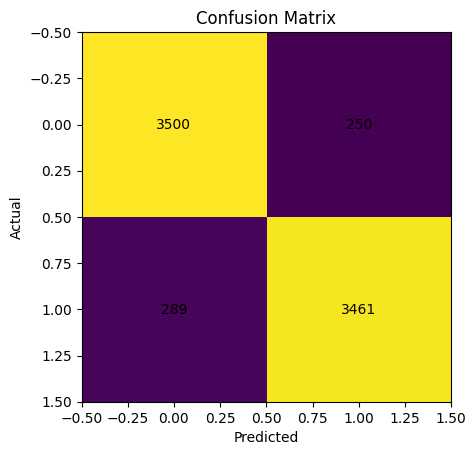

In [46]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

# Comparision

Freeze BERT layers and train classifier


In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

In [ ]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

In [ ]:
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

In [ ]:
exp1_results = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}

Fine-tune last 2 layers of BERT


In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

for layer in model.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

In [ ]:
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

In [ ]:
exp2_results = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}

In [50]:
import pandas as pd

results_df = pd.DataFrame([exp1_results, exp2_results],
                          index=["Frozen BERT", "Last 2 Layers Tuned"])

print(results_df)

                     accuracy  precision    recall        f1
Frozen BERT          0.923733   0.909747  0.940800  0.925013
Last 2 Layers Tuned  0.928133   0.932633  0.922933  0.927758


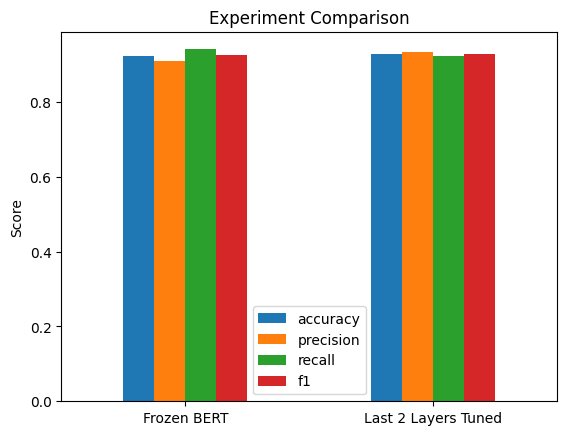

In [49]:
results_df.plot(kind='bar')
plt.title("Experiment Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# Expected Observations

Fine-tuning improves performance over frozen BERT
Training only classifier is insufficient for complex NLP tasks
Partial fine-tuning (last layers) gives a good balance of speed + performance